# Daybook — Sleep Data Exploration

Visual sanity check for the sleep-stage classifier inputs. Confirms data shape, time alignment, and gives an intuition for what HR/HRV/respiratory rate look like across the night.

In [1]:
import sys, os
from pathlib import Path
# Ensure we can import the classifier package even if notebook started elsewhere
INFERENCE_DIR = Path.cwd()
if INFERENCE_DIR.name != "inference":
    # If launched from a parent, fix up
    for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "classifier" / "data.py").exists():
            os.chdir(p)
            INFERENCE_DIR = p
            break
sys.path.insert(0, str(INFERENCE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from classifier.data import list_sessions, load_session
from classifier.features import expand_labels_to_epochs, compute_session_features

sns.set_theme(style="white", context="notebook")
pd.options.display.max_columns = 50

## 1. Eligible sessions

In [2]:
sessions = list_sessions()
print(f"Eligible sessions: {len(sessions)}")
sessions.head()

Eligible sessions: 249


,id,user_id,started_at,ended_at,duration_seconds,n_stage_segments,n_hr_readings
0,b17e06be-068b-4b9c-8afc-b67a2fa1b482,61c18d4c-1c20-408a-bd5f-f5f88fd9922f,2022-12-03 06:26:27+00:00,2022-12-03 13:00:57+00:00,23670,23,91
1,7459c226-3235-4864-8fe1-1dad6a6f70c2,61c18d4c-1c20-408a-bd5f-f5f88fd9922f,2022-12-05 03:48:42+00:00,2022-12-05 13:55:42+00:00,36420,41,136
2,afe9b4db-0480-46b7-b60f-f02418da3ec9,61c18d4c-1c20-408a-bd5f-f5f88fd9922f,2022-12-06 07:50:35+00:00,2022-12-06 13:57:05+00:00,21990,21,80
3,98a0077a-43ee-4297-bb77-b3a88d723828,61c18d4c-1c20-408a-bd5f-f5f88fd9922f,2022-12-07 04:03:17+00:00,2022-12-07 13:49:47+00:00,35190,40,136
4,c415ae37-6e09-4b4d-928f-c9a2b0ffa84d,61c18d4c-1c20-408a-bd5f-f5f88fd9922f,2022-12-10 05:37:33+00:00,2022-12-10 11:22:33+00:00,20700,17,66


In [3]:
print("Duration (hours):")
print((sessions['duration_seconds'] / 3600).describe().round(2))
print("\nStage segments per session:")
print(sessions['n_stage_segments'].describe().round(1))
print("\nHR readings per hour:")
hr_per_h = sessions['n_hr_readings'] / (sessions['duration_seconds'] / 3600)
print(hr_per_h.describe().round(1))

Duration (hours):
count    249.00
mean       7.17
std        1.98
min        4.03
25%        5.68
50%        6.91
75%        8.40
max       13.38
Name: duration_seconds, dtype: float64

Stage segments per session:
count    249.0
mean      27.5
std        9.9
min        7.0
25%       21.0
50%       26.0
75%       33.0
max       80.0
Name: n_stage_segments, dtype: float64

HR readings per hour:
count    249.0
mean      16.0
std       41.4
min        5.7
25%       13.0
50%       13.6
75%       13.8
max      667.0
dtype: float64


## 2. Pick a representative session

Not the longest, not the shortest — pick a session near the median duration with above-median data density so the plots actually show something.

In [4]:
# Pick a session near median duration AND median data density
sessions = sessions.copy()
sessions['hr_per_hour'] = sessions['n_hr_readings'] / (sessions['duration_seconds'] / 3600)
median_dur = sessions['duration_seconds'].median()
median_hr = sessions['hr_per_hour'].median()
# Choose closest to medians, preferring slightly above on data density
ranked = sessions.assign(
    score=(sessions['duration_seconds'] - median_dur).abs() / 3600
        + (median_hr - sessions['hr_per_hour']).clip(lower=0)
).sort_values('score')
chosen = ranked.iloc[0]
print(f"Chosen session: {chosen['id']}")
print(f"  Duration: {chosen['duration_seconds']/3600:.1f}h")
print(f"  Stage segments: {chosen['n_stage_segments']}")
print(f"  HR readings: {chosen['n_hr_readings']}")
bundle = load_session(chosen['id'])
print(f"  Sensors shape: {bundle.sensors.shape}")
print(f"  Kinds present: {bundle.sensors['kind'].value_counts().to_dict()}")

Chosen session: 7dbaca05-af9c-49db-85ae-e8df4bac034d
  Duration: 6.9h
  Stage segments: 24
  HR readings: 95


  Sensors shape: (148, 3)
  Kinds present: {'heart_rate': 95, 'respiratory_rate': 41, 'spo2': 10, 'hrv': 2}


## 3. Sensor timeseries with stage labels

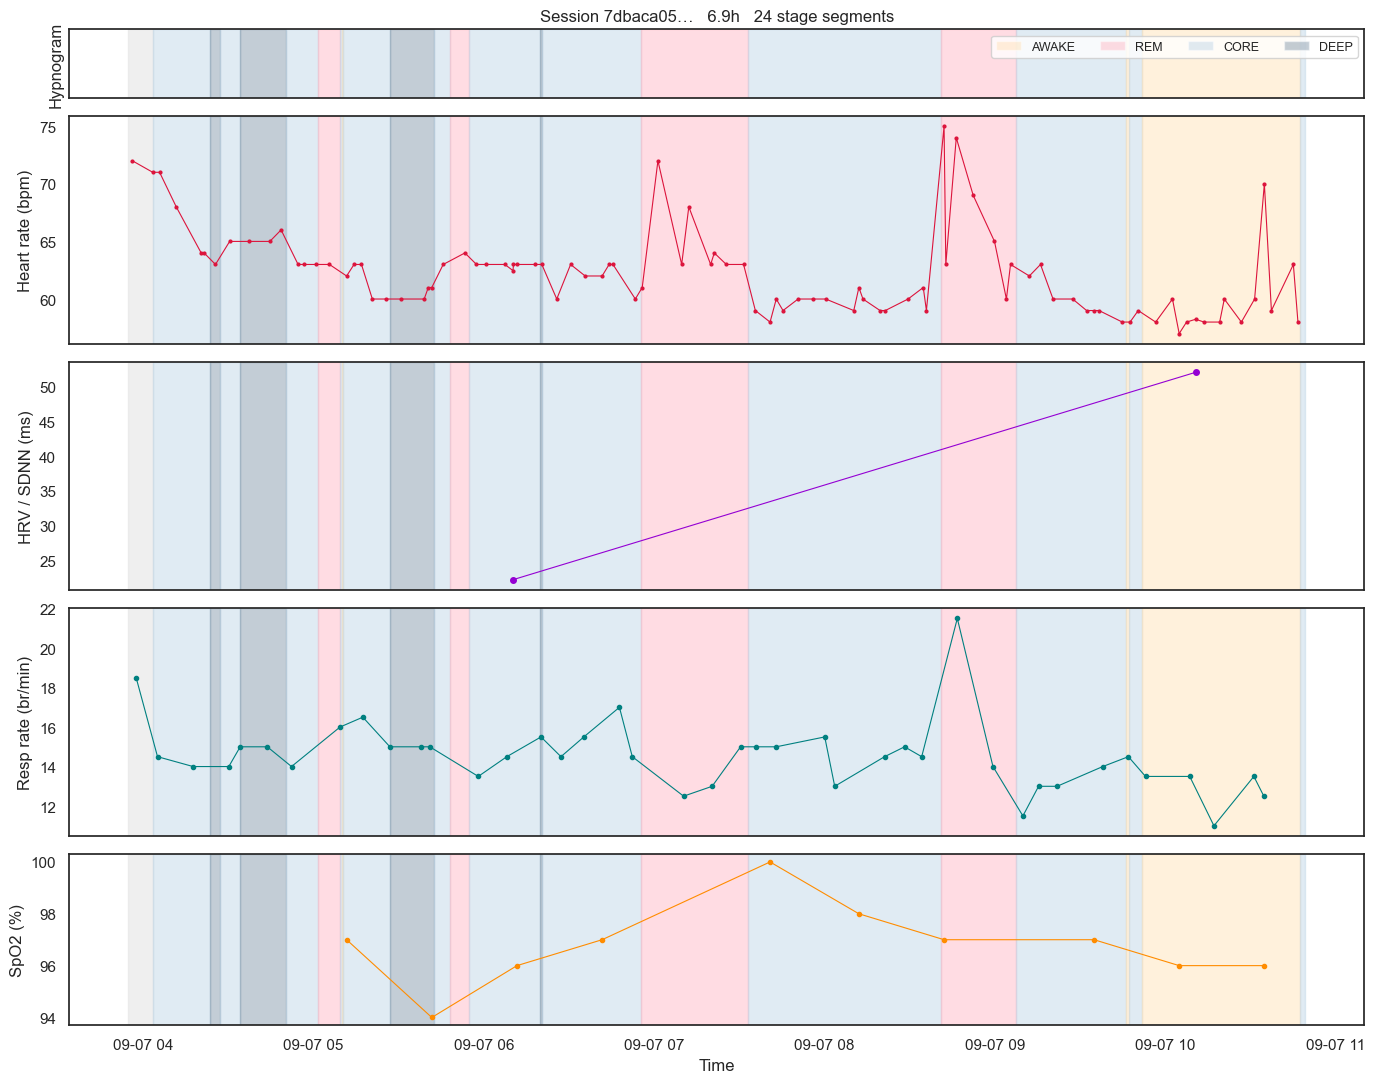

In [5]:
STAGE_COLORS = {
    "AWAKE": "#ffe0b3",  # warm
    "REM":   "#ffb3c1",  # pink — the star of the show
    "CORE":  "#bcd4e6",  # soft blue
    "DEEP":  "#7a90a4",  # deep blue
    "UNKNOWN": "#dddddd",
}

def add_stage_bands(ax, labels_df, session_end):
    """Color background regions per stage segment."""
    labels = labels_df.sort_values('epoch_start_at').reset_index(drop=True)
    for i, row in labels.iterrows():
        start = row['epoch_start_at']
        end = labels['epoch_start_at'].iloc[i+1] if i+1 < len(labels) else session_end
        color = STAGE_COLORS.get(row['stage'], "#dddddd")
        ax.axvspan(start, end, color=color, alpha=0.45, zorder=0)

fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={"height_ratios": [0.6, 2, 2, 2, 1.5]})

# Panel 0: hypnogram (just stage labels)
ax = axes[0]
add_stage_bands(ax, bundle.labels, bundle.ended_at)
ax.set_yticks([])
ax.set_title(f"Session {chosen['id'][:8]}…   {chosen['duration_seconds']/3600:.1f}h   {len(bundle.labels)} stage segments")
ax.set_ylabel("Hypnogram")

# Panel 1: HR
ax = axes[1]
add_stage_bands(ax, bundle.labels, bundle.ended_at)
hr = bundle.sensors.query("kind == 'heart_rate'")
ax.plot(hr['recorded_at'], hr['value'], "-o", markersize=2, lw=0.8, color="crimson")
ax.set_ylabel("Heart rate (bpm)")

# Panel 2: HRV (SDNN)
ax = axes[2]
add_stage_bands(ax, bundle.labels, bundle.ended_at)
hrv = bundle.sensors.query("kind == 'hrv'")
ax.plot(hrv['recorded_at'], hrv['value'], "-o", markersize=4, lw=0.8, color="darkviolet")
ax.set_ylabel("HRV / SDNN (ms)")

# Panel 3: Respiratory rate
ax = axes[3]
add_stage_bands(ax, bundle.labels, bundle.ended_at)
resp = bundle.sensors.query("kind == 'respiratory_rate'")
ax.plot(resp['recorded_at'], resp['value'], "-o", markersize=3, lw=0.8, color="teal")
ax.set_ylabel("Resp rate (br/min)")

# Panel 4: SpO2
ax = axes[4]
add_stage_bands(ax, bundle.labels, bundle.ended_at)
sp = bundle.sensors.query("kind == 'spo2'")
ax.plot(sp['recorded_at'], sp['value'], "-o", markersize=3, lw=0.8, color="darkorange")
ax.set_ylabel("SpO2 (%)")
ax.set_xlabel("Time")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, alpha=0.45, label=s) for s, c in STAGE_COLORS.items() if s != "UNKNOWN"]
axes[0].legend(handles=legend_patches, loc="upper right", ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

## 4. Per-epoch features

In [6]:
feats = compute_session_features(bundle)
print(f"Feature DataFrame: {feats.shape}")
print(f"\nStage distribution (after dropping UNKNOWN):")
print(feats['stage'].value_counts())
print(f"\nFeature columns:")
print(list(feats.columns))
print(f"\nNaN rate per feature (worst 15):")
print((feats.isnull().mean() * 100).sort_values(ascending=False).head(15).round(1))

Feature DataFrame: (812, 32)

Stage distribution (after dropping UNKNOWN):
stage
CORE     468
REM      158
AWAKE    114
DEEP      72
Name: count, dtype: int64

Feature columns:
['session_id', 'epoch_start_at', 'stage', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'hr_median', 'hr_slope', 'hr_n', 'hr_pct_above_baseline', 'hrv_mean', 'hrv_std', 'hrv_min', 'hrv_max', 'hrv_n', 'resp_mean', 'resp_std', 'resp_n', 'spo2_mean', 'spo2_std', 'spo2_min', 'spo2_n', 'time_of_night_frac', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week', 'is_weekend', 'hr_lag1_mean', 'hr_lag3_mean', 'hr_lag5_mean']

NaN rate per feature (worst 15):
hrv_std                  100.0
spo2_std                 100.0
resp_std                  97.8
hrv_mean                  97.3
hrv_max                   97.3
hrv_min                   97.3
spo2_min                  86.5
spo2_mean                 86.5
hr_std                    67.6
hr_slope                  67.6
resp_mean                 48.0
hr_lag5_mean          

## 5. Feature distributions by stage

Boxplots: does the feature actually look different across stages? If `hr_mean` looks identical across AWAKE/REM/CORE/DEEP, the model has no signal to work with.

/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/50668194.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/50668194.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/50668194.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats, x=

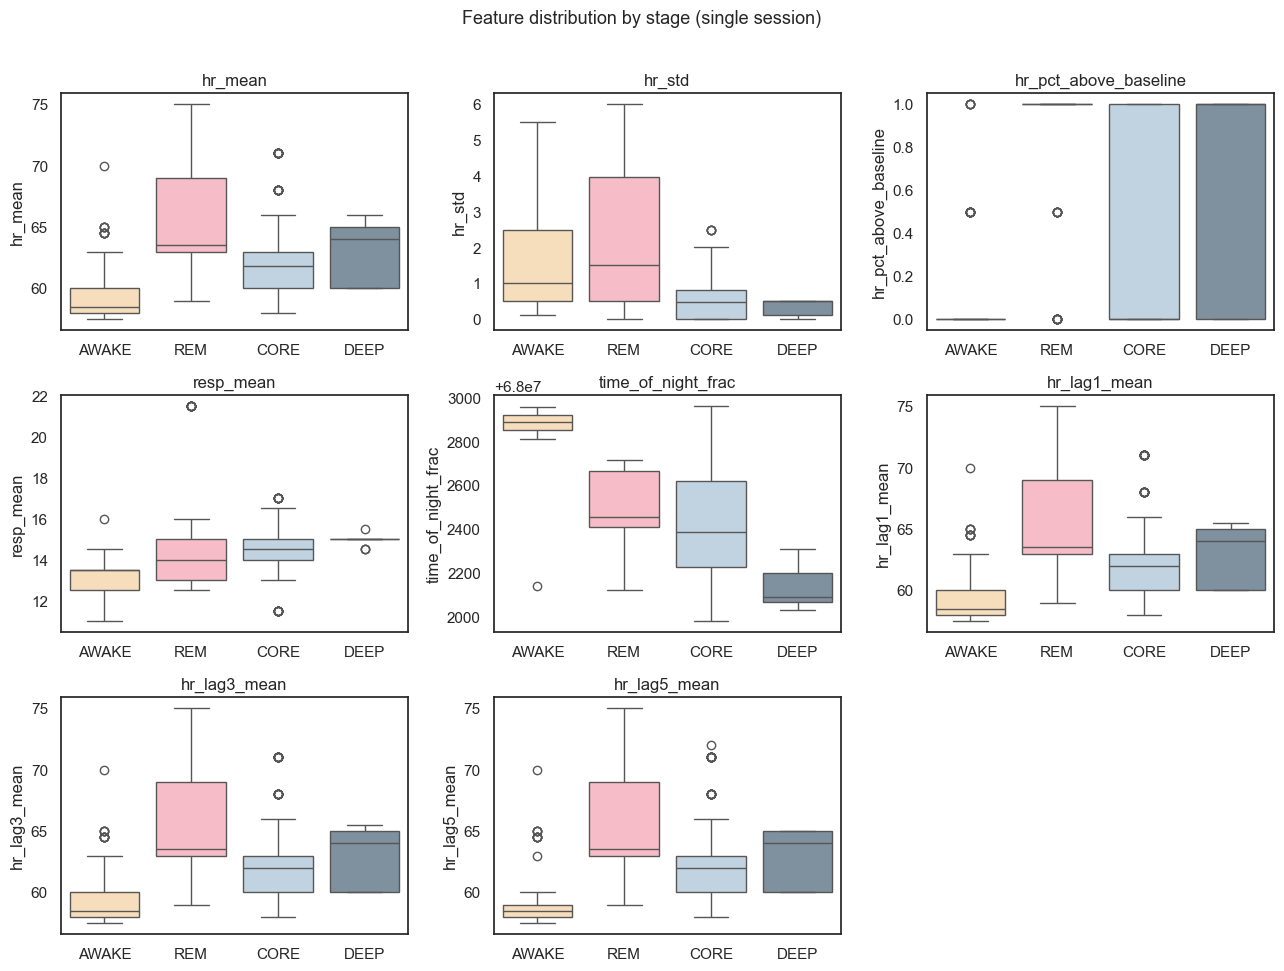

In [7]:
key_features = [
    "hr_mean", "hr_std", "hr_pct_above_baseline",
    "resp_mean", "time_of_night_frac",
    "hr_lag1_mean", "hr_lag3_mean", "hr_lag5_mean",
]
key_features = [f for f in key_features if f in feats.columns]

n = len(key_features)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = axes.flatten() if nrows > 1 else [axes] if n == 1 else axes

stage_order = ["AWAKE", "REM", "CORE", "DEEP"]
palette = {"AWAKE": STAGE_COLORS["AWAKE"], "REM": STAGE_COLORS["REM"],
           "CORE": STAGE_COLORS["CORE"], "DEEP": STAGE_COLORS["DEEP"]}

for i, f in enumerate(key_features):
    sns.boxplot(data=feats, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
    axes[i].set_title(f)
    axes[i].set_xlabel("")

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature distribution by stage (single session)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Across multiple sessions

The single-session view above is suggestive but noisy. Let's check the same boxplots on features pooled across 10 sessions.

In [8]:
from classifier.data import load_sessions
from classifier.features import compute_all_features

sample_ids = sessions['id'].head(10).tolist()
bundles_10 = load_sessions(sample_ids)
feats_10 = compute_all_features(bundles_10)
print(f"Pooled features: {feats_10.shape} from {len(bundles_10)} sessions")
print(f"Stage distribution:")
print(feats_10['stage'].value_counts())

[1/10] b17e06be-068b-4b9c-8afc-b67a2fa1b482 epochs=789 in 0.06s
[2/10] 7459c226-3235-4864-8fe1-1dad6a6f70c2 epochs=1214 in 0.06s
[3/10] afe9b4db-0480-46b7-b60f-f02418da3ec9 epochs=733 in 0.03s
[4/10] 98a0077a-43ee-4297-bb77-b3a88d723828 epochs=1173 in 0.06s
[5/10] c415ae37-6e09-4b4d-928f-c9a2b0ffa84d epochs=690 in 0.03s


[6/10] c5e1bcf1-0e20-4929-8c9f-efbd56224df1 epochs=910 in 0.05s
[7/10] 5010624d-719f-47a6-b4b9-2be2ea19415b epochs=1180 in 0.06s
[8/10] 4e2c320e-9449-4487-bca6-2ae5a994823b epochs=886 in 0.04s
[9/10] 6c992ae4-57ff-470b-887b-16f9d9d22263 epochs=758 in 0.03s
[10/10] abc238cf-f49a-4233-8e53-e4d2bb641e21 epochs=1018 in 0.05s
Pooled features: (9351, 32) from 10 sessions
Stage distribution:
stage
CORE     5992
REM      1990
DEEP      964
AWAKE     405
Name: count, dtype: int64


/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/2953600325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_10, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/2953600325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_10, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
/var/folders/8v/0104br1n43l9bfyf7_x5645m0000gn/T/ipykernel_96168/2953600325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=

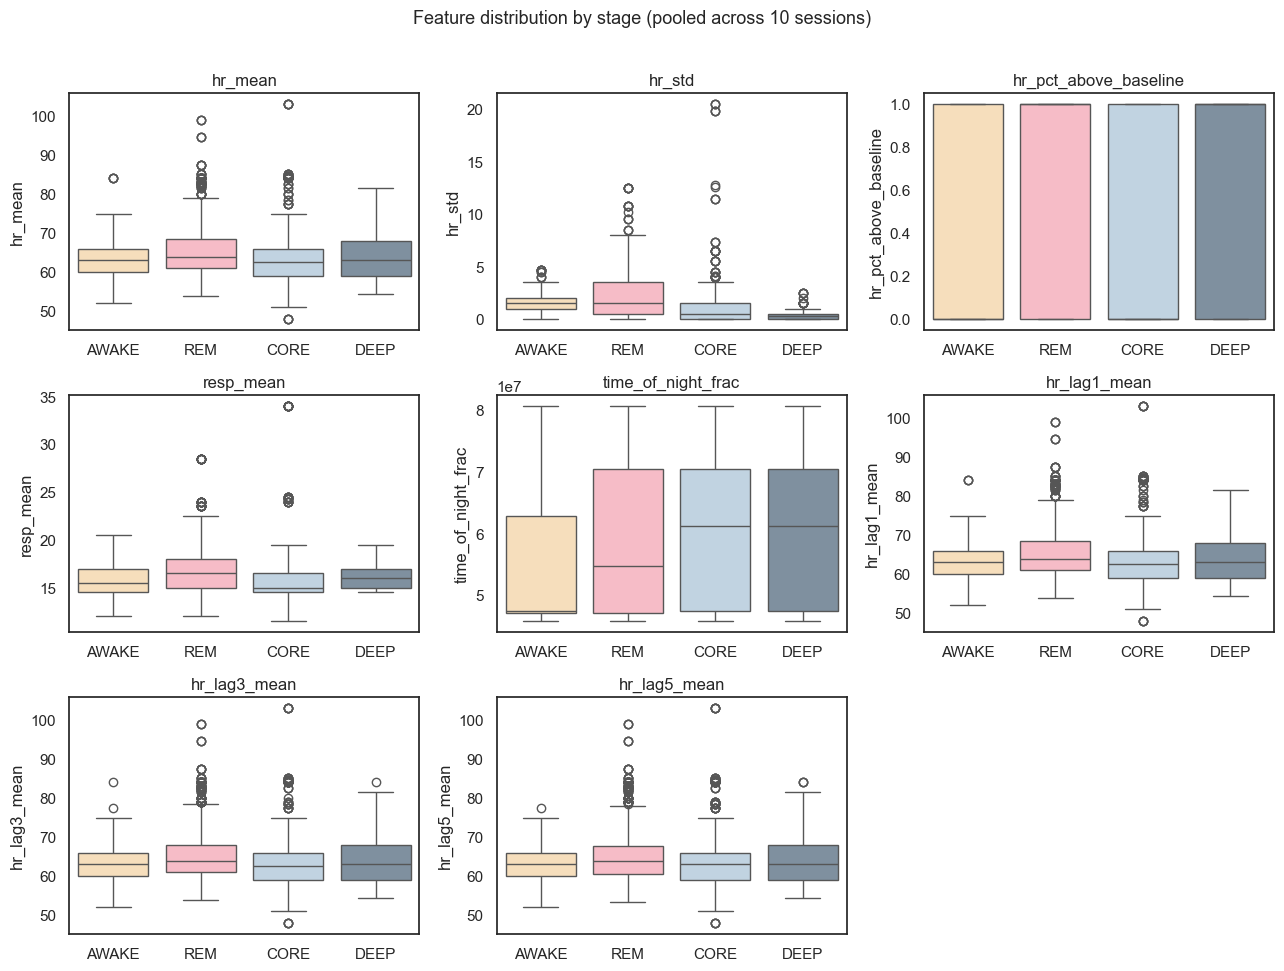

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = axes.flatten() if nrows > 1 else [axes]
for i, f in enumerate(key_features):
    sns.boxplot(data=feats_10, x="stage", y=f, order=stage_order, palette=palette, ax=axes[i])
    axes[i].set_title(f)
    axes[i].set_xlabel("")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Feature distribution by stage (pooled across {len(bundles_10)} sessions)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7. What this tells us

_TODO: fill in observations after running. What features visibly separate REM from CORE? Is HRV signal too sparse to be useful? Does respiratory rate look like a strong discriminator? Are NaN rates concerning anywhere?_